# Intelligent Automation 2026/27- Assignment 1

To be delivered until 2026-10-09 23:59:59.

**Submission Notes**:
- Create a folder in your group's GitHub repository to solve this assignment. Copy this notebook into that folder.
- You should commit regularly to your repository the answers to the questions in this notebook. If you do not, your grade will be penalized by 1/20 points.
- After running the entire notebook (including graphs and outputs), save the notebook as a .pdf file, by going to File - Print - Destination: Save as PDF.
- Create a .zip file containing both the .ipynb file (the notebook itself) and the .pdf and submit it in Fénix.

# Problem description

The dataset for this assignment contains information on students from two Portuguese secondary schools enrolled in a mathematics course.
Each row corresponds to one student and includes demographic and family background variables (e.g., basic personal and household characteristics), school-related variables (e.g., school context, study habits, past failures), behavioral and lifestyle indicators (e.g., free time, going out, alcohol use), and the grades for the three school periods, on a 0–20 scale.

The goal is to predict the performance of the students in the final period.
First, the problem will be approached as a classification task, predicting whether a student will pass (G3 >= 10) or fail (G3 < 10) the course.
Then, the problem will be approached as a regression task, predicting the actual final grade (G3).

A detailed description of all variables (family context, behavioral, school performance, etc.) is provided in the file `feature_description.txt`.

# Part 1 - Data exploration **(4.00)**

##### **1.1.** Load the dataset from the CSV file `mathematics_grades.csv`. **(0.25)**

In [2]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("mathematics_grades.csv")

df.head(357)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,failed
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,True
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,True
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,False
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,False
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,MS,M,20,U,LE3,A,2,2,services,services,...,5,4,4,5,4,11,9,9,9,True
353,MS,M,17,U,LE3,T,3,1,services,services,...,4,5,3,4,2,3,14,16,16,False
354,MS,M,21,R,GT3,T,1,1,other,other,...,5,3,3,3,3,3,10,8,7,True
355,MS,M,18,R,LE3,T,3,2,services,other,...,4,1,3,4,5,0,11,12,10,False


##### **1.2.** Identify the feature types of each variable in the dataset. **(1.50)**

In [3]:
# Ordinal categorical variables
ordinal_cols = [
    "Medu", "Fedu", "traveltime", "studytime",
    "famrel", "freetime", "goout", "Dalc",
    "Walc", "health"
]

# Numerical discrete variables
numeric_disc_cols = [
    "age", "failures", "absences",
    "G1", "G2", "G3"
]

# Numerical continuous variables
numeric_cont_cols = []

# Binary categorical variables
binary_cols = [
    "school", "sex", "address", "famsize",
    "Pstatus", "schoolsup", "famsup", "paid",
    "activities", "nursery", "higher",
    "internet", "romantic"
]

# Nominal categorical variables
nominal_cols = [
    "Mjob", "Fjob", "reason", "guardian"
]

# Boolean variable
boolean_cols = ["failed"]

# Identify the feature type of each variable
summary_df = pd.DataFrame({
    "Data Type": df.dtypes,
    "Feature Type": [
        "Ordinal categorical" if col in ordinal_cols
        else "Numerical discrete" if col in numeric_disc_cols
        else "Numerical continuous" if col in numeric_cont_cols
        else "Binary categorical" if col in binary_cols
        else "Boolean" if col in boolean_cols
        else "Nominal categorical"
        for col in df.columns
    ]
})

display(summary_df)


,Data Type,Feature Type
school,object,Binary categorical
sex,object,Binary categorical
age,int64,Numerical discrete
address,object,Binary categorical
famsize,object,Binary categorical
Pstatus,object,Binary categorical
Medu,int64,Ordinal categorical
Fedu,int64,Ordinal categorical
Mjob,object,Nominal categorical
Fjob,object,Nominal categorical


##### **1.3** Check if the dataset has missing values. If so, discard any row that has a missing value. **(0.25)**

In [4]:
#.isnull() outputs True(0) for missing values and False(1) for non-missing values | .sum() sums the number of missing values of a single collumn
print(df.isnull().sum())

#if there's missing values, the new dataframe is stored without the rows correspondent 
df = df.dropna()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
failed        0
dtype: int64


##### **1.4.** Make a pairplot of the numerical variables, colored by the `failed` variable. **(0.50)**

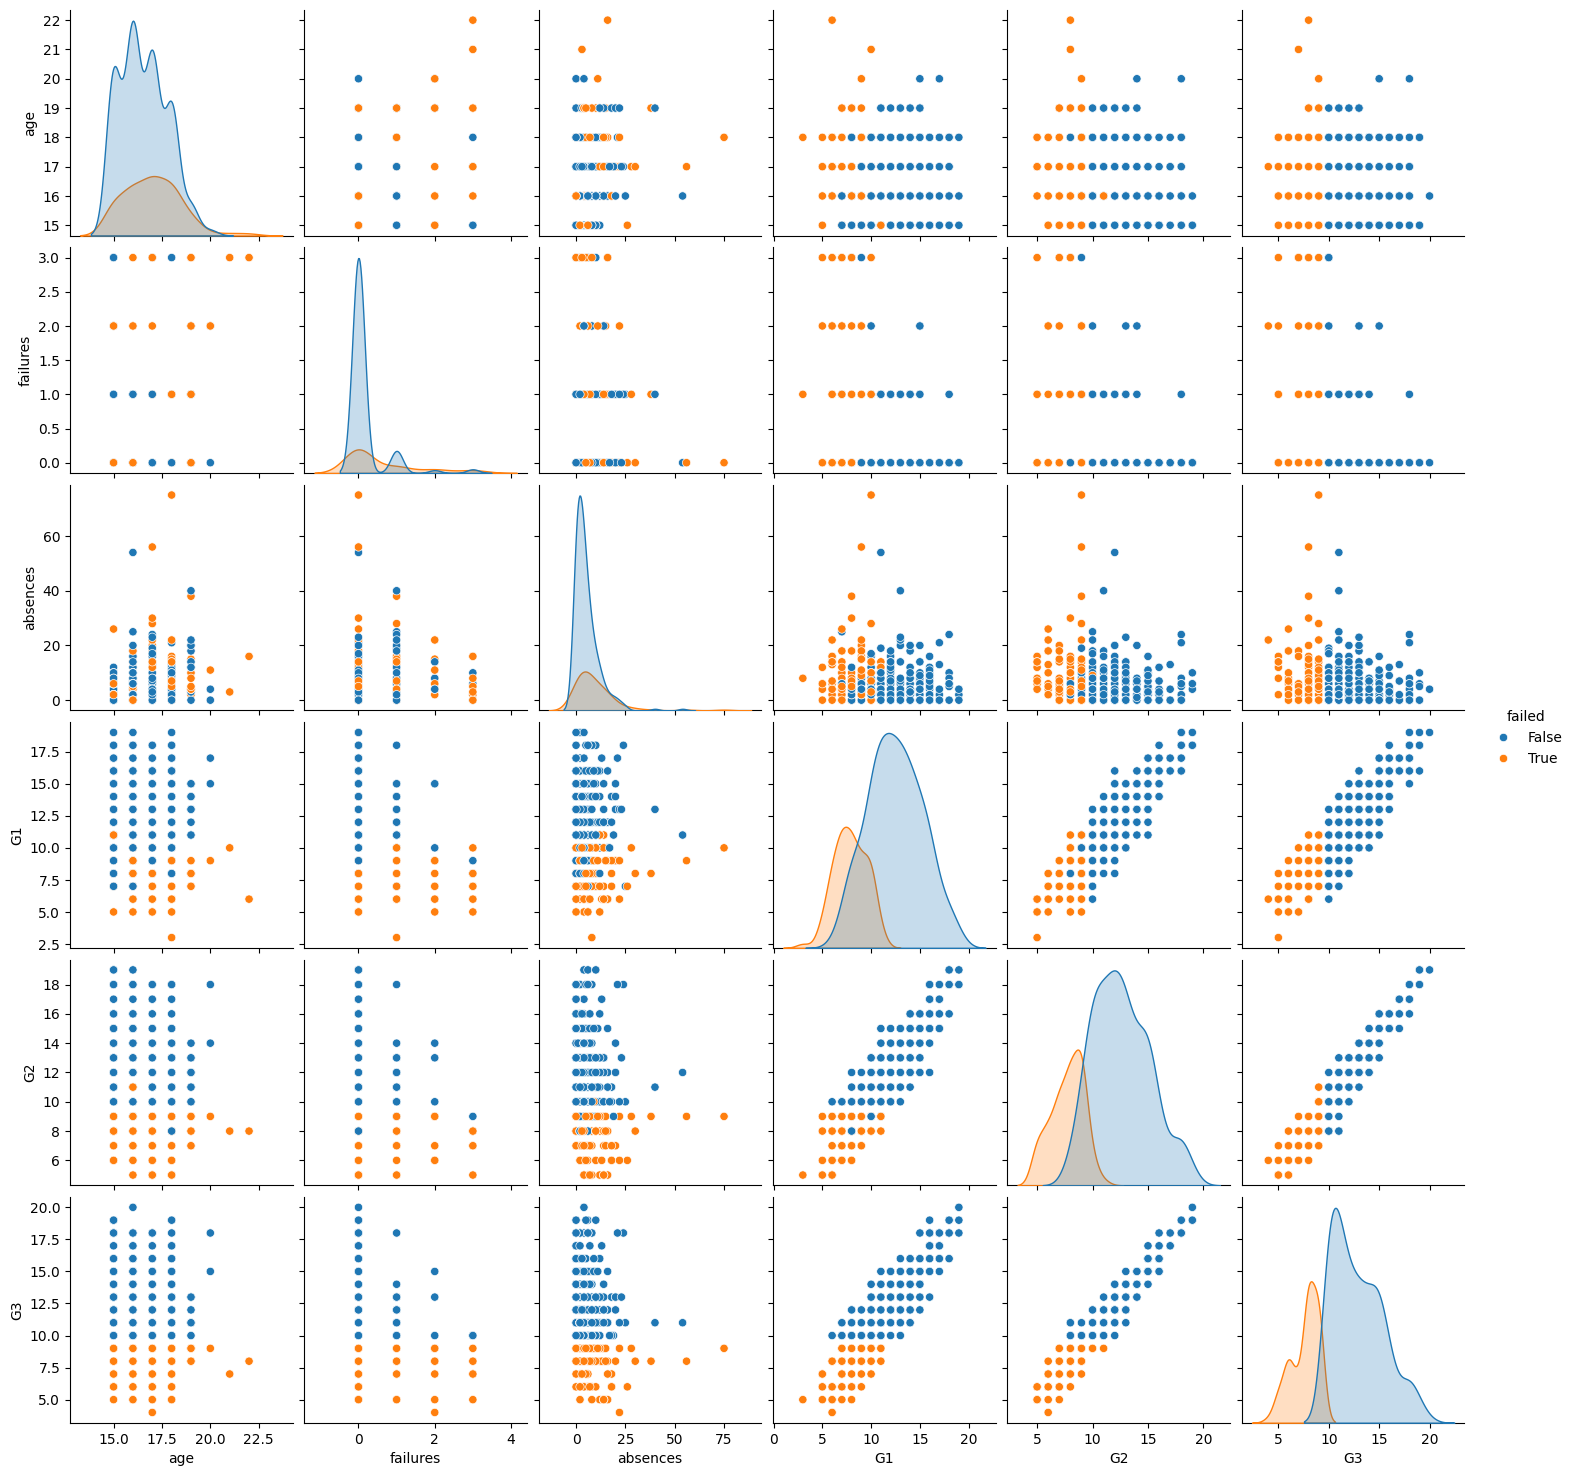

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt



numerical_variables = numeric_disc_cols + numeric_cont_cols


sns.pairplot(df, vars=numerical_variables, hue='failed')

plt.show()

##### **1.5.** Make bar plots for each categorical variable, showing the counts for each category, colored by the `failed` variable. **(0.50)**

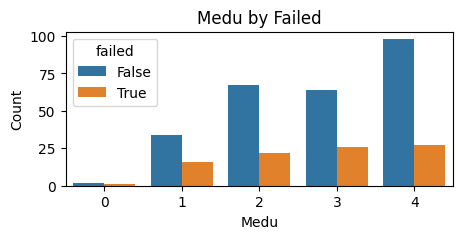

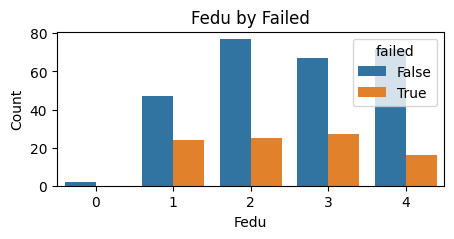

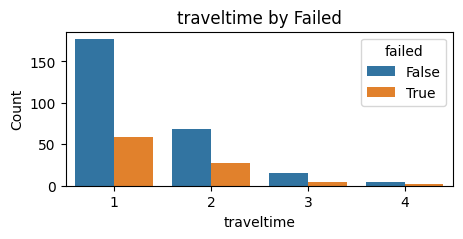

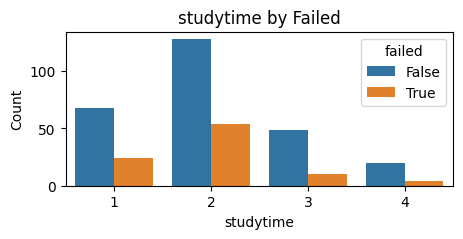

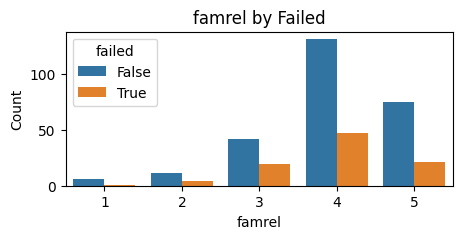

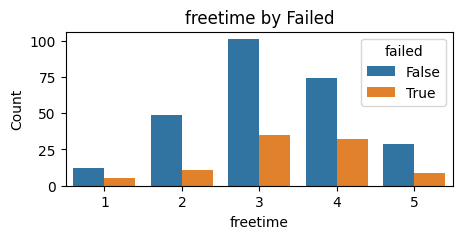

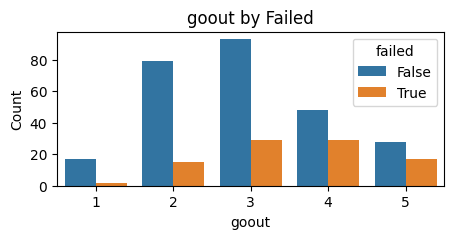

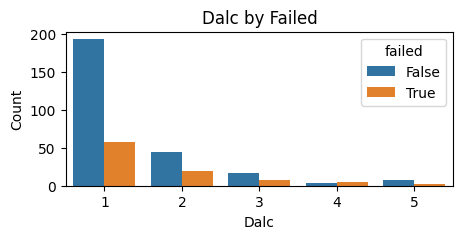

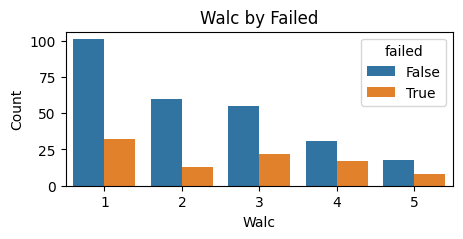

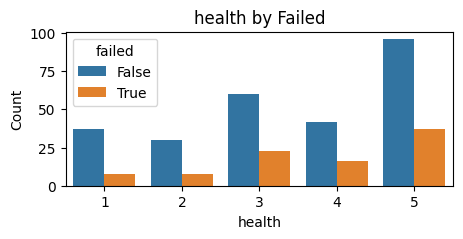

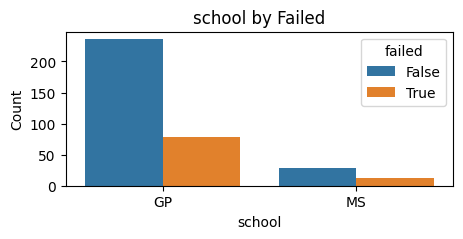

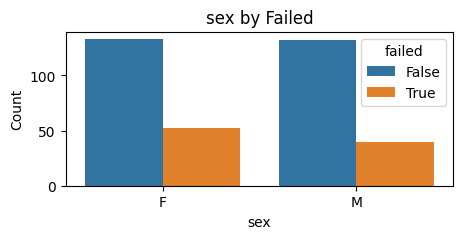

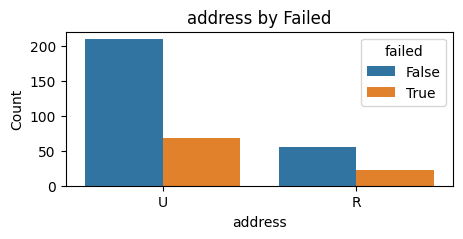

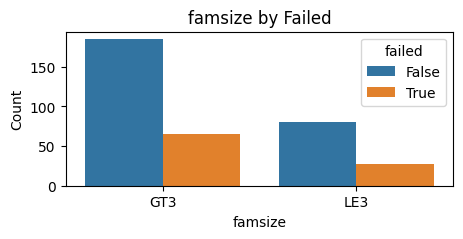

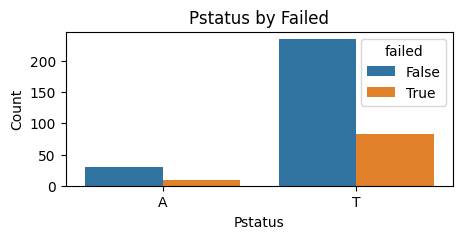

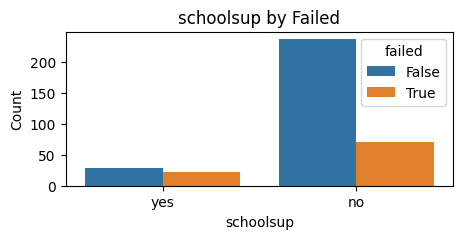

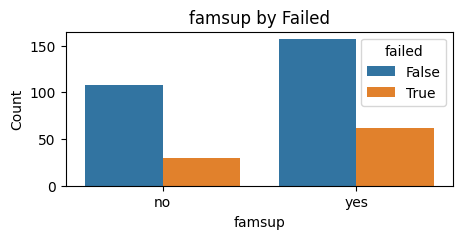

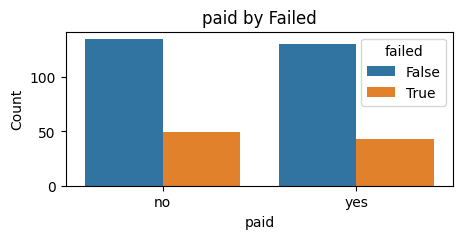

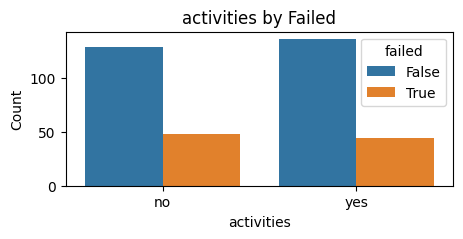

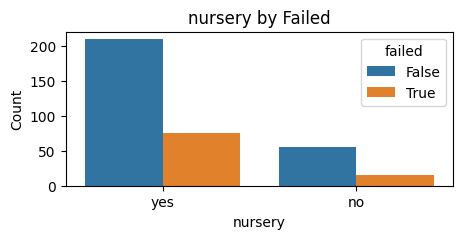

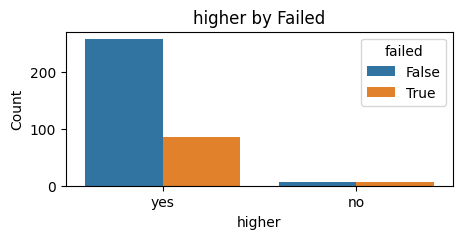

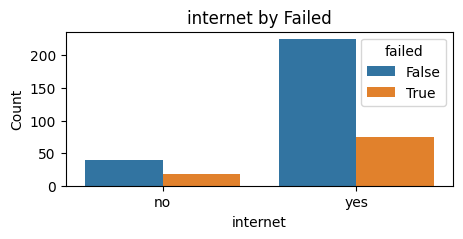

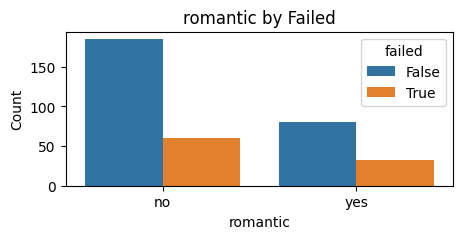

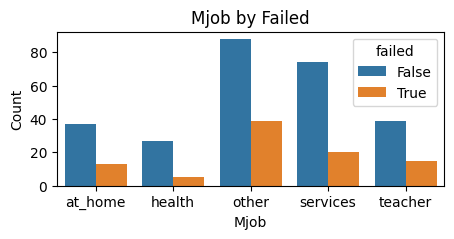

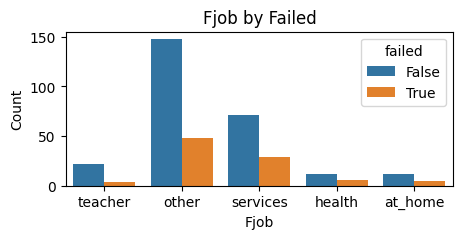

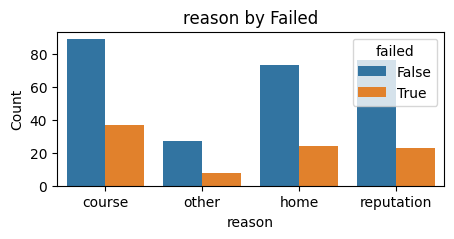

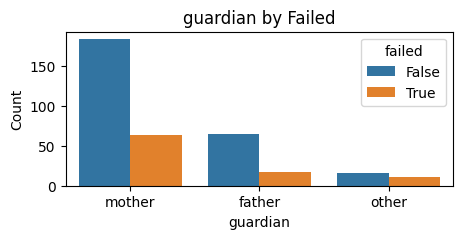

In [6]:
categorical_variables = ordinal_cols + binary_cols + nominal_cols


for variable in categorical_variables:
    plt.figure(figsize=(5, 2))
    
    sns.countplot(data=df, x=variable, hue='failed')
    
    plt.title(f'{variable} by Failed')
    plt.xlabel(variable)
    plt.ylabel('Count')
    plt.show()

##### **1.6.** In each school, how many students live in a rural area and do not have internet access at home? **(0.50)**

In [7]:
rural_no_internet = df[(df['address'] == 'R') & (df['internet'] == 'no')]

counts_by_school = rural_no_internet.groupby('school').size()
print("Number of rural students without internet by school:") 
print(counts_by_school)

Number of rural students without internet by school:
school
GP    17
MS     7
dtype: int64


##### **1.7.** Split the dataset into a training set (80%) and a test set (20%). **(0.50)**

In [8]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.20, random_state=10)

print("Training set:", train.shape)
print("Test set:", test.shape)

Training set: (285, 34)
Test set: (72, 34)


# Part 2 - Classification **(7.50)**

##### You'll start by approaching the problem as a classification task, predicting whether a student will pass (G3 >= 10) or fail (G3 < 10) the course. Consider the variable `failed` as the target variable.

##### **2.1.** Which performance metric do you think are most important for this prediction task, and why? Justify your answer in the context of supporting students who may struggle academically. **(2.00)**

The most important performance metric for this classification task is recall, particularly for the positive class (failed = True), which represents students who fail the course.
Recall measures the proportion of students who actually fail that are correctly identified by the model. In this context, minimizing false negatives is particularly important. A false negative occurs when the model predicts that a student will pass, but the student actually fails. As a result, that student may not receive the academic support or intervention they need.
Precision should also be considered, as it measures the proportion of students predicted to fail who actually fail. Low precision would mean that many students are incorrectly identified as being at risk, potentially leading to an inefficient allocation of educational resources.
The F1-score is also useful because it combines precision and recall into a single metric. Furthermore, accuracy alone may be misleading, especially if the dataset contains significantly more students who pass than students who fail.
Therefore, recall should be prioritized, while precision and F1-score should be used as complementary metrics. In the context of academic support, identifying as many struggling students as possible is generally more important than avoiding every false alarm, since missing a student who needs help may have more serious consequences.

##### **2.2.** Build a logistic regression model to predict whether a student will pass or fail the course, using as predictor the feature `absences`. Evaluate the performance of the model on the test set using a confusion matrix, accuracy, precision, recall, f1-score and the metric you selected in question 2.1. **(0.50)**

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Select the predictor and target variable
X_train = train[['absences']]
X_test = test[['absences']]

y_train = train['failed']
y_test = test['failed']

# Create and train the logistic regression model
model = LogisticRegression(random_state=10)
model.fit(X_train, y_train)

# Predict the test set
y_pred = model.predict(X_test)

# Evaluate the model
cm = confusion_matrix(y_test, y_pred)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Display the results
print("Confusion Matrix (rows=actual, cols=predicted):")
print(cm)

print(f"\nAccuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")

Confusion Matrix (rows=actual, cols=predicted):
[[56  1]
 [13  2]]

Accuracy: 0.8056
Precision: 0.6667
Recall: 0.1333
F1-score: 0.2222


##### **2.3.** The model you built in question 2.2 likely does not perform very well. Explain why this is the case, considering the distribution of the predictor and the response. How can you improve the model? **(2.00)**

The logistic regression model performs poorly mainly due to the limited predictive power of the variable absences and the class imbalance in the target variable failed. Although students who fail have a higher average number of absences (9.55) than those who pass (5.19), there is considerable overlap between the two groups. Some students pass despite having many absences, while others fail even with very few absences. Therefore, the number of absences alone is not sufficient to reliably distinguish between students who pass and those who fail.
Furthermore, the dataset is imbalanced, with approximately 74.2% of students passing and only 25.8% failing. This imbalance, combined with the limited predictive information provided by absences, contributes to the model predicting the majority class (failed = False) in most cases. As observed in Question 2.2, the model achieves an accuracy of 75%, but a recall of only 5.26%, correctly identifying just 1 out of 19 students who actually fail. This demonstrates that accuracy alone can be misleading, particularly when our main objective is to identify students who may need academic support.
To improve the model, we could include additional predictors, such as previous failures, study time and previous grades (G1 and G2, if available at prediction time), as these may provide more relevant information about students' academic performance. Another possibility would be to use class_weight='balanced' in logistic regression, assigning greater importance to the minority class during training. We could also lower the default classification threshold of 0.5 to increase recall, although this might lead to more false positives and lower precision. Additionally, oversampling techniques could be applied to the training set to address class imbalance.
Overall, the model's poor performance is mainly explained by the overlapping distributions of absences and the imbalance between the two target classes. Since the primary objective is to identify students at risk of academic failure, improving recall should be prioritized while also monitoring precision and the F1-score to maintain an appropriate balance between identifying struggling students and avoiding unnecessary interventions.


##### **2.4.** Consider now the variable `studytime` as the predictor and assume it is numerical. Build a logistic regression model to predict whether a student will pass or fail the course. Evaluate the performance of the model on the test set using a confusion matrix, accuracy, precision, recall, f1-score and the metric you selected in question 2.1. **(0.50)**

Note: Use `sklearn.linear_model.LogisticRegression(class_weight='balanced')` for your logistic regression model.

In [10]:
# Select studytime as a numerical predictor
X_train_num = train[['studytime']]
X_test_num = test[['studytime']]

# Select the target variable
y_train_num = train['failed']
y_test_num = test['failed']

# Create and train a balanced logistic regression model
model_num = LogisticRegression(class_weight='balanced')
model_num.fit(X_train_num, y_train_num)

# Predict the test set
y_pred_num = model_num.predict(X_test_num)

# Evaluate model performance
print("Confusion Matrix:")
print(confusion_matrix(y_test_num, y_pred_num))

print("Accuracy:", accuracy_score(y_test_num, y_pred_num))
print("Precision:", precision_score(y_test_num, y_pred_num))
print("Recall:", recall_score(y_test_num, y_pred_num))
print("F1-score:", f1_score(y_test_num, y_pred_num))

Confusion Matrix:
[[43 14]
 [10  5]]
Accuracy: 0.6666666666666666
Precision: 0.2631578947368421
Recall: 0.3333333333333333
F1-score: 0.29411764705882354


##### **2.5.** Repeat question 2.4, but now considering `studytime` as a categorical variable. **(0.50)**

In [11]:
# Convert studytime into categorical variables using one-hot encoding
X_train_cat = pd.get_dummies(
    train[['studytime']],
    columns=['studytime'],
    dtype=int
)

X_test_cat = pd.get_dummies(
    test[['studytime']],
    columns=['studytime'],
    dtype=int
)

# Ensure the test set has the same columns as the training set
X_test_cat = X_test_cat.reindex(
    columns=X_train_cat.columns,
    fill_value=0
)

# Select the target variable
y_train_cat = train['failed']
y_test_cat = test['failed']

# Create and train the logistic regression model
model_cat = LogisticRegression(class_weight='balanced')
model_cat.fit(X_train_cat, y_train_cat)

# Predict the test set
y_pred_cat = model_cat.predict(X_test_cat)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test_cat, y_pred_cat))

print("Accuracy:", accuracy_score(y_test_cat, y_pred_cat))
print("Precision:", precision_score(y_test_cat, y_pred_cat))
print("Recall:", recall_score(y_test_cat, y_pred_cat))
print("F1-score:", f1_score(y_test_cat, y_pred_cat))

Confusion Matrix:
[[30 27]
 [ 9  6]]
Accuracy: 0.5
Precision: 0.18181818181818182
Recall: 0.4
F1-score: 0.25


##### **2.6.** What is the difference between the two models you built in questions 2.4 and 2.5? Plot the predictions of each model over the range of `studytime` values in the test set. What are the advantages and disadvantages of each approach? **(2.00)**


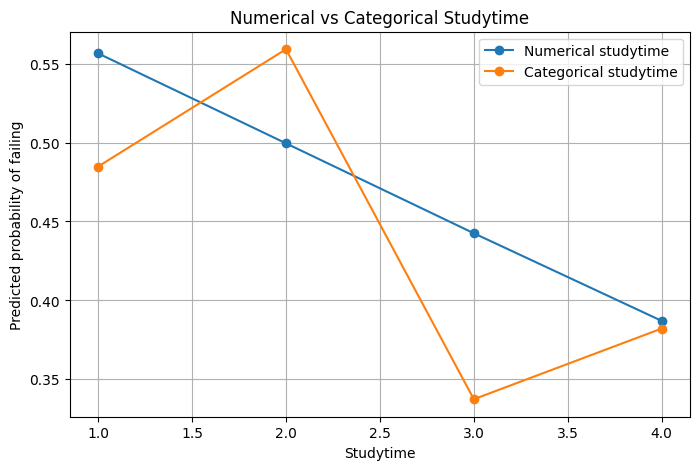

In [12]:
# Get the unique studytime values from the test set
studytime_values = sorted(test['studytime'].unique())

# Numerical model predictions
X_plot_num = pd.DataFrame({'studytime': studytime_values})

pred_num = model_num.predict_proba(X_plot_num)[:, 1]

# Categorical model predictions
X_plot_cat = pd.DataFrame({'studytime': studytime_values})

X_plot_cat = pd.get_dummies(
    X_plot_cat,
    columns=['studytime'],
    dtype=int
)

# Ensure the same columns as the training set
X_plot_cat = X_plot_cat.reindex(
    columns=X_train_cat.columns,
    fill_value=0
)

pred_cat = model_cat.predict_proba(X_plot_cat)[:, 1]

# Plot both models
plt.figure(figsize=(8, 5))

plt.plot(
    studytime_values,
    pred_num,
    marker='o',
    label='Numerical studytime'
)

plt.plot(
    studytime_values,
    pred_cat,
    marker='o',
    label='Categorical studytime'
)

plt.xlabel('Studytime')
plt.ylabel('Predicted probability of failing')
plt.title('Numerical vs Categorical Studytime')
plt.legend()
plt.grid()
plt.show()

The main difference between the two models is how the variable studytime is represented. In Question 2.4, studytime is treated as a numerical variable, meaning that the logistic regression model assumes a constant effect on the log-odds of failing for each unit increase in studytime. As shown in the graph, the predicted probability of failing decreases consistently as studytime increases, from approximately 55.65% for level 1 to 38.70% for level 4.
In Question 2.5, studytime is treated as a categorical variable using one-hot encoding. This approach allows the model to estimate a different effect for each studytime category without assuming a linear relationship between the categories and the log-odds of failing. As a result, the predicted probabilities do not follow a strictly decreasing pattern. For example, the probability of failing increases from approximately 48.47% at level 1 to 55.91% at level 2, before decreasing to 33.74% at level 3 and increasing slightly to 38.22% at level 4.
The main advantage of the numerical approach is its simplicity, as it requires fewer parameters and takes advantage of the natural ordering of the studytime categories. This can make the model easier to interpret and less prone to overfitting. However, its main disadvantage is the assumption of a constant effect on the log-odds between consecutive studytime levels, which may not accurately represent the relationship in the data.
On the other hand, the categorical approach is more flexible because it allows each studytime level to have an independent effect on the predicted probability of failing. This may capture patterns that the numerical model cannot represent. However, it requires more parameters, does not directly use the ordering of the categories and may be more prone to overfitting, particularly when some categories contain few observations.
Overall, the numerical approach provides a simpler model with a consistent decreasing trend in the predicted probability of failing, while the categorical approach captures more variation between studytime levels. Although the categorical model achieves a slightly higher recall in the test set (40% compared to 33.33%), it has lower accuracy, precision and F1-score. Therefore, neither approach is necessarily better in all aspects, and the choice should depend on the model's predictive performance, complexity and the objective of identifying students at risk of academic failure.


# Part 3 - Regression (3.50)

##### In this part of the assignment, you'll approach the problem as a regression task, predicting the actual final grade `G3`. Use the same training and test sets you created in Part 1.

##### **3.1.** Build a linear regression model to predict the final grade `G3`, using as predictor the feature `G2`. Evaluate the performance of the model on the test set using Mean Squared Error (MSE) and R-squared ($R^2$). **(0.50)**

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Select the predictor and target from the existing train and test sets
X_train = train[['G2']]
X_test = test[['G2']]

y_train = train['G3']
y_test = test['G3']

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display results
print("Intercept:", model.intercept_)
print("Coefficient for G2:", model.coef_[0])
print("MSE:", mse)
print("R-squared:", r2)

Intercept: 0.19698708368915696
Coefficient for G2: 0.9956367421007684
MSE: 0.7691185839870914
R-squared: 0.9142612145584353


##### **3.2.** Print the equation of the model you built in question 3.1. Plot the predictions of the model as a function of the inputs, along with the actual data points from the test set. Interpret the coefficients of the model. **(1.00)**


Linear Regression Model:
G3 = 0.1970 + 0.9956 * G2

Interpretation:
Intercept: 0.1970
When G2 = 0, the predicted G3 is approximately 0.1970.

Slope: 0.9956
For every 1-point increase in G2, the predicted G3 increases by approximately 0.9956 points.


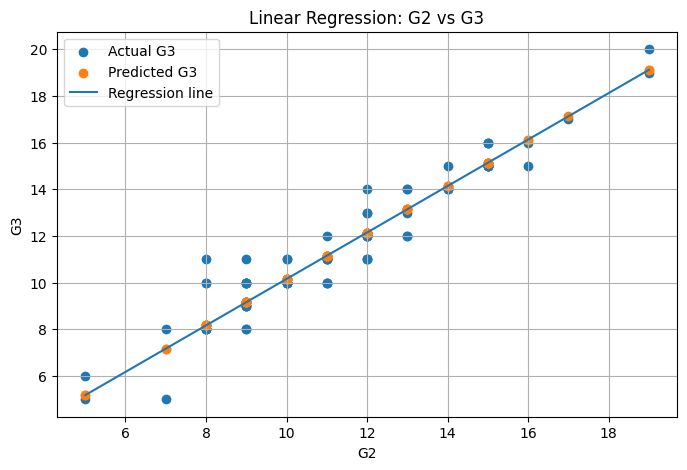

In [15]:
import matplotlib.pyplot as plt

# Get the coefficients from the model trained in question 3.1
intercept = model.intercept_
slope = model.coef_[0]

# Print the regression equation
print("Linear Regression Model:")
print(f"G3 = {intercept:.4f} + {slope:.4f} * G2")

# Interpret the coefficients
print("\nInterpretation:")
print(f"Intercept: {intercept:.4f}")
print(f"When G2 = 0, the predicted G3 is approximately {intercept:.4f}.")

print(f"\nSlope: {slope:.4f}")
print(f"For every 1-point increase in G2, the predicted G3 increases by "
      f"approximately {slope:.4f} points.")

# Sort the test inputs for plotting the regression line
X_test_sorted = X_test.sort_values(by="G2")
y_pred_sorted = model.predict(X_test_sorted)

# Plot actual data and predictions
plt.figure(figsize=(8, 5))

# Actual test data
plt.scatter(
    X_test["G2"],
    y_test,
    label="Actual G3"
)

# Predicted values
plt.scatter(
    X_test["G2"],
    y_pred,
    label="Predicted G3"
)

# Regression line
plt.plot(
    X_test_sorted["G2"],
    y_pred_sorted,
    label="Regression line"
)

# Labels and title
plt.xlabel("G2")
plt.ylabel("G3")
plt.title("Linear Regression: G2 vs G3")
plt.legend()
plt.grid(True)

plt.show()

The linear regression model predicts the final grade G3 based on the second-period grade G2. The intercept is approximately 0.1970, representing the predicted final grade when G2 is equal to zero. The coefficient of G2 is approximately 0.9956, indicating that a one-point increase in the second-period grade is associated with an average increase of approximately 0.996 points in the predicted final grade.
The graph shows a strong positive linear relationship between G2 and G3, with the actual observations generally close to the regression line. This suggests that the second-period grade is a strong predictor of the final grade, although individual predictions may differ from the observed values.

##### **3.3.** Build a linear regression model to predict the final grade `G3`, using as predictors all features except the variables related to the grades (`G1`, `G2`, `G3`, `failed`). Explain the choices you made. Evaluate the performance of the model on the test set using Mean Squared Error (MSE) and R-squared ($R^2$). Plot the predicted vs actual values of `G3` for the test set. **(1.00)**

Mean Squared Error (MSE): 7.4746
R-squared (R²): 0.1668


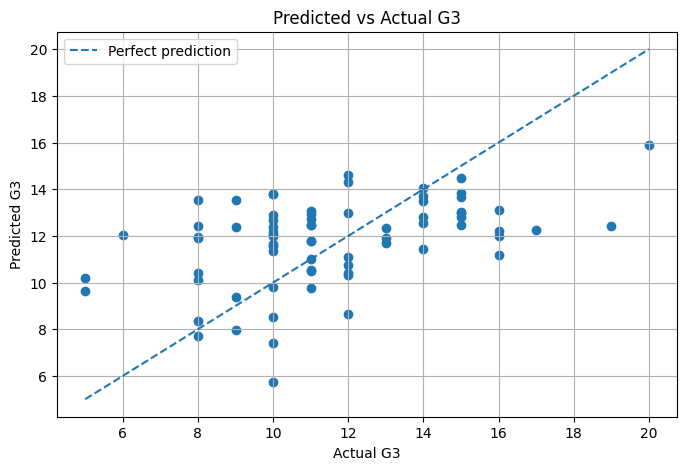

In [16]:
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Exclude grade-related variables
features_to_exclude = ["G1", "G2", "G3", "failed"]

# Use the train and test sets created in Part 1
X_train = train.drop(columns=features_to_exclude)
X_test = test.drop(columns=features_to_exclude)

y_train = train["G3"]
y_test = test["G3"]

# Identify categorical and numerical features
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns

numerical_features = X_train.select_dtypes(
    include="number"
).columns

# Preprocess the features
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         categorical_features),

        ("num", "passthrough", numerical_features)
    ]
)

# Create the regression pipeline
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

# Train the model
model.fit(X_train, y_train)

# Predict G3 for the test set
y_pred = model.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

# Plot predicted vs actual grades
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

# Perfect prediction reference line
min_grade = min(y_test.min(), y_pred.min())
max_grade = max(y_test.max(), y_pred.max())

plt.plot(
    [min_grade, max_grade],
    [min_grade, max_grade],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Predicted vs Actual G3")
plt.legend()
plt.grid(True)

plt.show()

##### **3.4.** In terms of application, what is the difference between building a model to predict student performance using the grades of the previous periods (as in question 3.1) versus using other features (as in question 3.3)? When would each approach be more appropriate? **(1.00)**

The main difference between the two approaches is the type of information used to predict students' final grades and the stage of the academic year at which the models can be applied. The model developed in Question 3.1 uses the second-period grade (G2) to predict the final grade (G3). Since previous academic performance is strongly associated with future performance, this approach generally provides more accurate predictions. In our case, the model achieved an MSE of approximately 0.7691 and an R² of 0.9143, indicating strong predictive performance. However, it can only be used once the second-period grades are available, making it more appropriate for identifying students at risk of failing towards the end of the academic year.
On the other hand, the model developed in Question 3.3 uses demographic, family, school-related and lifestyle characteristics instead of previous grades. Although this approach achieved a higher MSE of approximately 7.4746 and a lower R² of 0.1668, it may be useful for identifying students who could experience academic difficulties at an earlier stage, provided that the required information is already available. This could allow schools to implement preventive measures and provide additional support before academic performance deteriorates.
Therefore, the grades-based model is more appropriate when the main objective is to obtain accurate predictions later in the academic year, while the model based on other characteristics may be more suitable for early identification and intervention. The choice between the two approaches depends on the timing of the prediction, the availability of the data and the specific educational objective.

# Part 4 - Cross-validation (4.00)

##### **4.1.** Explain the concept of cross-validation and its importance in evaluating machine learning models. **(1.00)**

Cross-validation is a resampling technique used to estimate how well a machine learning model is expected to perform on unseen data. Instead of relying on a single training and validation split, the available training data is divided into several subsets, and the model is trained and evaluated multiple times. In each iteration, one subset is used for validation while the remaining subsets are used for training. The results are then combined, usually by calculating the average performance across the different iterations.
Cross-validation is important because the performance obtained from a single data split can vary depending on which observations are selected for training and validation. By evaluating the model on different subsets, cross-validation provides a more robust estimate of its generalization performance and makes more efficient use of the available data. It is also useful for comparing different models, selecting hyperparameters and reducing the risk of choosing a model based on an unusually favorable data split.

##### **4.2.** Describe how K-fold cross-validation works. What values of K should be used? Justify. **(1.00)**

K-fold cross-validation is a resampling technique in which the available training data is divided into K approximately equal-sized subsets, called folds. The model is trained using K−1 folds and evaluated on the remaining fold. This process is repeated K times, with each fold being used exactly once as the validation set. The performance results obtained from the different iterations are then combined, usually by calculating their average, to estimate how well the model is expected to perform on unseen data.
The most commonly recommended values are K = 5 or K = 10, as they generally provide a good balance between bias, variance and computational cost. When K is too small, each model is trained on a smaller proportion of the available data, which can lead to a more biased estimate of the test error. On the other hand, when K is very large, such as in Leave-One-Out Cross-Validation (K = n), the models are trained on almost the entire dataset, reducing this source of bias but increasing computational cost. Furthermore, the training sets become highly similar, which can result in a higher variance of the cross-validation estimate. Therefore, using 5 or 10 folds is generally a good compromise, providing a reliable evaluation without excessive computational cost.

##### **4.3.** Explain how K-Fold cross-validation should be done to choose the classification threshold for the logistic regression model of Part 2. **(2.00)**

K-Fold cross-validation can be used to select an appropriate classification threshold for the logistic regression model developed in Part 2. Since logistic regression estimates the probability of belonging to the positive class (failed = True), a classification threshold is required to convert these probabilities into predicted classes. Instead of using the default threshold of 0.5, cross-validation allows us to evaluate different thresholds and select one based on the model's performance.
First, the original test set should be kept separate, and only the training data should be divided into K approximately equal-sized folds, typically using K = 5 or K = 10. Since the dataset is imbalanced, Stratified K-Fold could be used to preserve approximately the same proportion of students who pass and fail in each fold. For each iteration, a logistic regression model is trained on K−1 folds, and the predicted probabilities of failing are calculated for the remaining validation fold. Different classification thresholds, such as values between 0.1 and 0.9, are then applied to these probabilities, and the corresponding performance metrics are calculated.
This process is repeated across all K folds, and the average performance is calculated for each threshold. Since recall was identified as the most important metric in Question 2.1, the selected threshold should prioritize identifying students who are at risk of failing. However, precision should also be considered, as choosing a threshold that is too low may lead to a large number of false positives. Therefore, an appropriate threshold would aim to achieve high recall while maintaining an acceptable level of precision.
After selecting the threshold based on the cross-validation results, the logistic regression model should be retrained using the complete training dataset. The selected threshold is then applied to the predicted probabilities obtained from the separate test set, and the final performance is evaluated using the confusion matrix, accuracy, precision, recall and F1-score. This approach prevents the test set from influencing the threshold selection and provides an independent evaluation of the final model's generalization performance.

# Part 5 - GitHub (1.00)

**5.1.** Describe how your group used GitHub to track changes throughout the project and explain why maintaining a clear change history is important in data analysis and machine learning work. **(1.00)**

Our group used GitHub to track changes throughout the project by regularly pulling the latest version of the shared repository before making modifications, committing our work with clear and descriptive messages, and pushing the updated files back to GitHub. This workflow helped us keep the project synchronized, collaborate more efficiently, and ensure that group members had access to the latest version of the Jupyter Notebook.
Maintaining a clear change history is particularly important in data analysis and machine learning because it allows us to identify what was modified, when the changes were made, and who was responsible for them. It also makes it easier to detect and correct errors, recover previous versions, and understand how the code, data preprocessing steps, and machine learning models evolved throughout the project. Furthermore, version control improves transparency, collaboration, and reproducibility by helping us identify the exact version of the code used to obtain specific results.